<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1><center>Blood Cell Anomaly Detection</center></h1>


# Data description

The target dataset was retrieved from Kaggle at https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025.

## Content

This dataset provides 5,880 blood cell records across 19 cell types — covering normal white blood cells, red blood cells, and platelets alongside 12 clinically significant abnormal cell types linked to leukemia, anemia, infections, and sickle cell disease.

Inspired by CytoDiffusion — published in Nature Machine Intelligence (2025) by researchers at University of Cambridge, UCL, and Queen Mary University of London.

## Objective

Set up and validate classifiers for binary anomaly detection and multi-class cell anomaly type categorization.

# Data import and Overview

In [1]:
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv('data/blood_cell_anomaly_detection.csv')

display(data.head())

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [3]:
data.shape

(5880, 36)

## Features description

In [4]:
list(data.columns)

['cell_id',
 'cell_type',
 'anomaly_label',
 'disease_category',
 'cell_diameter_um',
 'nucleus_area_pct',
 'chromatin_density',
 'cytoplasm_ratio',
 'circularity',
 'eccentricity',
 'granularity_score',
 'lobularity_score',
 'membrane_smoothness',
 'cell_area_px',
 'perimeter_px',
 'mean_r',
 'mean_g',
 'mean_b',
 'stain_intensity',
 'patient_age_group',
 'patient_sex',
 'wbc_count_per_ul',
 'rbc_count_millions_per_ul',
 'hemoglobin_g_dl',
 'hematocrit_pct',
 'platelet_count_per_ul',
 'mcv_fl',
 'mchc_g_dl',
 'dataset_source',
 'staining_protocol',
 'microscope_model',
 'magnification_x',
 'image_resolution_px',
 'cytodiffusion_anomaly_score',
 'cytodiffusion_classification_confidence',
 'labeller_confidence_score']

In [5]:
data.dtypes.value_counts().to_frame()

,count
float64,18
int64,10
str,8


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
anomaly_label,5880.0,0.319728,0.466411,0.0000,0.000000,0.00000,1.00000,1.00
cell_diameter_um,5880.0,10.176267,3.642051,1.0000,7.630000,10.05500,12.86000,21.18
nucleus_area_pct,5880.0,43.537976,33.419390,0.0000,0.000000,54.50000,72.30000,99.00
chromatin_density,5880.0,0.391394,0.310006,0.0000,0.000000,0.47950,0.63500,1.00
cytoplasm_ratio,5880.0,0.564173,0.335282,0.0500,0.276000,0.45200,1.00000,1.00
circularity,5880.0,0.769263,0.158219,0.1000,0.711000,0.80500,0.87900,1.00
eccentricity,5880.0,0.365458,0.201501,0.0000,0.214750,0.33100,0.45600,0.99
granularity_score,5880.0,1.882109,1.428336,0.0000,0.670000,1.32000,2.98000,6.00
lobularity_score,5880.0,1.769252,1.229362,1.0000,1.000000,1.00000,2.30000,7.20
membrane_smoothness,5880.0,0.842866,0.096033,0.2900,0.784000,0.85400,0.91800,1.00


In [7]:
data.describe(include='str')

,cell_id,cell_type,disease_category,patient_age_group,patient_sex,dataset_source,staining_protocol,microscope_model
count,5880,5880,5880,5880,5880,5880,5880,5880
unique,5880,19,8,3,2,3,3,3
top,CELL_005371,Neutrophil,Normal_WBC,Adult,F,PBC_Dataset,Giemsa,Olympus_BX51
freq,1,1100,2800,3276,2966,2351,2627,2398


- cell_id - unique cell ID
- cell_type - cell type label, categorical
- anomaly_label - anomaly label, binary
- disease_category - disease group, categorical
- cell_diameter_um - cell diameter in micrometres, numerical
- nucleus_area_pct - nucleus area as percentage of total cell area, numerical
- chromatin_density - chromatin compaction score, float in [0, 1]
- cytoplasm_ratio - cytoplasm-to-cell area ratio, float in [0, 1]
- circularity - shape circularity, float in [0, 1]
- eccentricity - elliptical elongation, float in [0, 1]
- granularity_score, float in [0, 6]
- lobularity_score, float in [1, 8]
- membrane_smoothness, float in [0, 1]
- cell_area_px, float
- perimeter_px, float
- mean_r, int in [0, 255]
- mean_g, int in [0, 255]
- mean_b, int in [0, 255]
- stain_intensity, float in [0, 1]
- patient_age_group, categorical
- patient_sex, categorical
- wbc_count_per_ul, white blood cell count per microlitre of blood, int
- rbc_count_millions_per_ul, red blood cell count in millions per microlitre, float
- hemoglobin_g_dl, haemoglobin concentration in g/dL, float
- hematocrit_pct, percentage of blood volume occupied by red blood cells, float
- platelet_count_per_ul, platelet count per microlitre, int
- mcv_fl, mean corpuscular volume in femtolitres, float
- mchc_g_dl, mean corpuscular haemoglobin concentration in g/dL, float
- dataset_source - source dataset label, categorical
- staining_protocol - staining method used, categorical
- microscope_model - microscope used for imaging, categorical
- magnification_x - objective magnification, ordinal
- image_resolution_px - image resolution in pixels, ordinal
- cytodiffusion_anomaly_score - cytoDiffusion model anomaly probability, float in [0, 1]
- cytodiffusion_classification_confidence - cytoDiffusion confidence in its cell type classification, float in [0, 1]
- labeller_confidence_score - human expert labeller confidence in the assigned cell type label, float in [0, 1]

# EDA

### Check ID uniqueness

In [8]:
data.shape[0] == len(data['cell_id'].unique())

True

The data does not contain any duplicate record, based on indexes.

## Data cleaning

Primary target is the binary variable `anomaly_label`, with `disease_category` providing details about the disease category. First I'll consider the former as target for binary classification by dropping the latter from the features, then I'll consider the latter as target for multilabel classification.

Features not relevant to our classification tasks will be dropped as well.

In [9]:
yy = data[['disease_category']]

In [10]:
data.drop(columns=['cell_id', 'disease_category', 'dataset_source', 'staining_protocol', 'microscope_model', 'magnification_x', 'image_resolution_px', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score'], inplace=True)

## Handle missing data

In [11]:
all(data.isnull().sum() == 0)

True

The dataset does not have any missing data.

## Data types

In [12]:
numerical_data = data.select_dtypes(include='number')

numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
anomaly_label,5880.0,0.319728,0.466411,0.000,0.00000,0.0000,1.000,1.00
cell_diameter_um,5880.0,10.176267,3.642051,1.000,7.63000,10.0550,12.860,21.18
nucleus_area_pct,5880.0,43.537976,33.419390,0.000,0.00000,54.5000,72.300,99.00
chromatin_density,5880.0,0.391394,0.310006,0.000,0.00000,0.4795,0.635,1.00
cytoplasm_ratio,5880.0,0.564173,0.335282,0.050,0.27600,0.4520,1.000,1.00
circularity,5880.0,0.769263,0.158219,0.100,0.71100,0.8050,0.879,1.00
eccentricity,5880.0,0.365458,0.201501,0.000,0.21475,0.3310,0.456,0.99
granularity_score,5880.0,1.882109,1.428336,0.000,0.67000,1.3200,2.980,6.00
lobularity_score,5880.0,1.769252,1.229362,1.000,1.00000,1.0000,2.300,7.20
membrane_smoothness,5880.0,0.842866,0.096033,0.290,0.78400,0.8540,0.918,1.00


Numerical data is on different ranges: it could require scaling depending on the classification model.

In [13]:
categorical_data = data.select_dtypes(include='str')

categorical_data.describe()

,cell_type,patient_age_group,patient_sex
count,5880,5880,5880
unique,19,3,2
top,Neutrophil,Adult,F
freq,1100,3276,2966


Categorical data can be converted later with one-hot encoding.

## Data correlations

,anomaly_label
circularity,-0.387010
granularity_score,-0.267309
chromatin_density,-0.224006
mean_g,-0.216478
membrane_smoothness,-0.142715
mean_b,-0.097764
lobularity_score,-0.077662
mean_r,-0.053536
nucleus_area_pct,-0.044660
stain_intensity,-0.042571


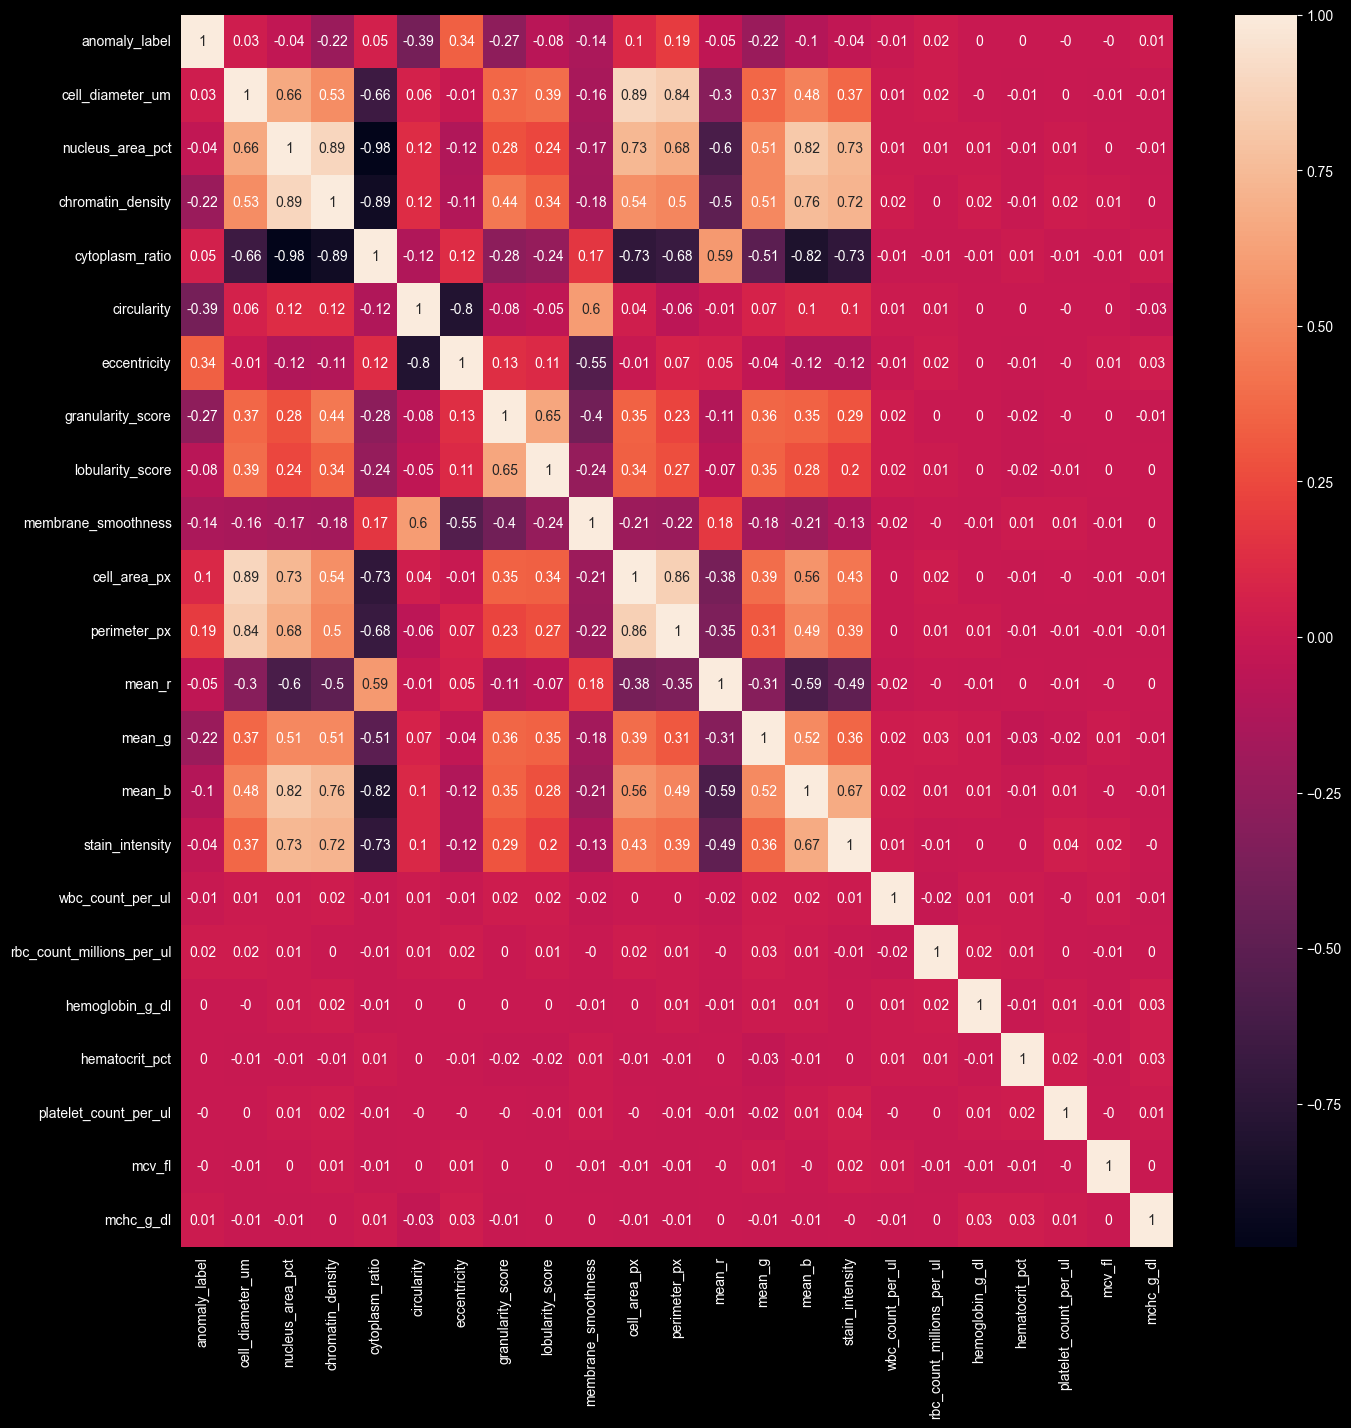

In [14]:
fig, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(round(numerical_data.corr(), 2), annot=True)
features_target_correlations = numerical_data.corr()['anomaly_label'].sort_values()

features_target_correlations.to_frame()

Most correlated features with the target are `circularity`, `eccentricity`, `granularity_score`.

Some features are strongly correlated with each other, such as the pairs (`cell_diameter_um`, `cell_area_px`), (`cell_diameter_um`, `perimeter_px`), (`nucleus_area_pct`, `chromatin_density`), (`cytoplasm_ratio`, `chromatin_density`), (`cytoplasm_ratio`, `nucleus_area_pct`), (`cytoplasm_ratio`, `chromatin_density`). This could cause problems of multicollinearity at modeling time: regularization to exclude multicollinear variables could be needed.

## Features encoding

I'm applying a OneHotEncoder with `drop=first` option to avoid the provision of multicollinear one-hot variables.

In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

one_hot = ColumnTransformer(transformers=[
	('one_hot', OneHotEncoder(drop='first'), categorical_data.columns)
], remainder='passthrough')
one_hot_data = one_hot.fit_transform(data)
data_1 = pd.DataFrame(data=one_hot_data,columns=one_hot.get_feature_names_out())
data_1.rename(columns=lambda c: c.split('__')[1], inplace=True)

data_1

,cell_type_Basophil,cell_type_Blast_Cell,cell_type_Elliptocyte,cell_type_Eosinophil,cell_type_Hypersegmented_Neutrophil,cell_type_Lymphocyte,cell_type_Monocyte,cell_type_Neutrophil,cell_type_Normal_RBC,cell_type_Platelet,...,mean_g,mean_b,stain_intensity,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,141.0,160.0,0.555,6352.0,4.44,11.7,43.4,257383.0,85.5,31.4
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,136.0,169.0,0.692,7709.0,4.90,13.9,42.2,302274.0,92.5,35.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,150.0,203.0,0.593,7451.0,5.72,16.1,39.2,229996.0,76.3,33.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,138.0,118.0,0.509,9196.0,3.42,14.6,54.1,130720.0,92.3,32.5
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,127.0,113.0,0.607,5898.0,5.36,14.6,36.7,228652.0,83.9,33.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,138.0,176.0,0.618,8894.0,5.37,12.7,37.3,310767.0,81.4,34.2
5876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,152.0,123.0,0.412,5499.0,4.12,17.1,33.2,180228.0,88.1,34.4
5877,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,128.0,134.0,0.454,9606.0,5.44,15.9,45.7,293938.0,86.7,34.0
5878,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,133.0,195.0,0.597,8021.0,5.19,13.8,42.1,298582.0,96.5,32.9


## Target distribution

,count
anomaly_label,
0,4000
1,1880


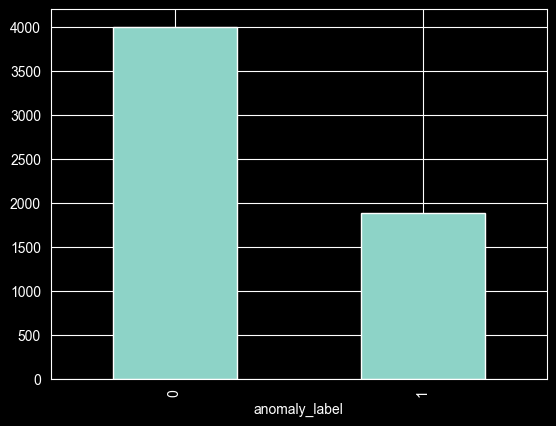

In [16]:
target_vcs = data['anomaly_label'].value_counts()
target_vcs.plot.bar()

target_vcs.to_frame()

Target is slightly imbalanced: I'll possibly address class imbalance at modeling time.

# Binary Classification - Model development

In [17]:
X = data_1[[col for col in data_1.columns if col !='anomaly_label']]
y = data_1['anomaly_label']

I'll stratify train and test set with respect to the target, so as to get the same target label distribution in both datasets. Since I'm getting very good results I'll increase the difficulty of this classification problem by considering a test size of 90% of the total data.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, stratify=y, random_state=0)

## Model #1 - Logistic Regression
Logistic regression requires features scaling: I'll employ a Pipeline involving a MinMaxScaler.

Solver = `liblinear` can be used for binary classification. I'll apply a grid search with cross-validation to identify the estimator with the best hyperparameters.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lr', LogisticRegression(solver='liblinear', random_state=0)),
])

params = {
    'lr__C': [0.1, 0.2, 0.5, 1, 2, 5, 10],
    'lr__l1_ratio': [0, 1],
}

grid = GridSearchCV(pipe, params, cv=5, n_jobs=-1, scoring='f1')
grid.fit(X_train, y_train)

best_estimator = grid.best_estimator_
best_estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-p

In [20]:
y_pred = best_estimator.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000      3600
         1.0      1.000     1.000     1.000      1692

    accuracy                          1.000      5292
   macro avg      1.000     1.000     1.000      5292
weighted avg      1.000     1.000     1.000      5292



Model #1 yielded perfect results with a test set sized 90% of the overall data. I'll now consider a test size of 99%.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, stratify=y, random_state=0)

In [22]:
grid = GridSearchCV(pipe, params, cv=5, n_jobs=-1, scoring='f1')
grid.fit(X_train, y_train)

best_estimator = grid.best_estimator_
best_estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-pen

In [23]:
y_pred = best_estimator.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

         0.0      1.000     0.890     0.942      3961
         1.0      0.811     1.000     0.896      1861

    accuracy                          0.925      5822
   macro avg      0.905     0.945     0.919      5822
weighted avg      0.940     0.925     0.927      5822



Even by using only 1% of available data the model yields relatively high performances.

# Model selection

Model #1, given by a simple logistic regressor, already resulted well-suitable for cell anomaly binary classification.

# Multilabel Classification - Model development
Given the very good results the first model was able to yield even with very small training data, I'll consider the binary classification task solved and focus on the secondary target: predicting the `disease_category`.

## Target distribution

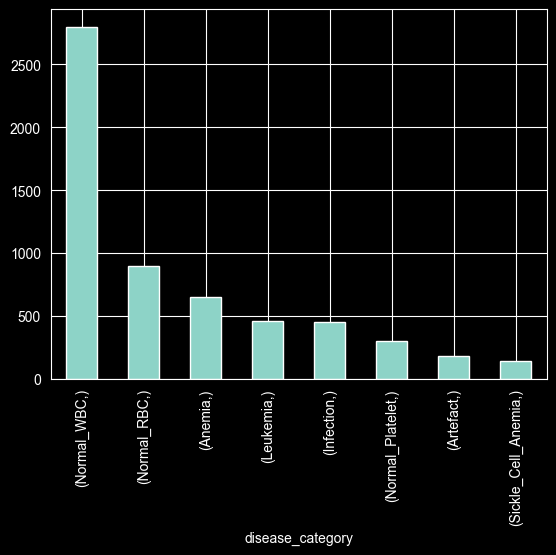

In [24]:
yy.value_counts().plot.bar();

Target classes are imbalanced: I'll evaluate class weighting possibilities.

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
yy = pd.Series(label_encoder.fit_transform(yy.values.ravel()), name='disease_category')

yy.to_frame()

,disease_category
0,2
1,2
2,6
3,5
4,5
...,...
5875,4
5876,0
5877,0
5878,2


## Data correlations

In [26]:
numerical_data.drop('anomaly_label', axis=1, inplace=True)
numerical_data = pd.concat([numerical_data, yy], axis=1)
features_target_correlations = numerical_data.corr()['disease_category'].sort_values()

features_target_correlations.to_frame()

,disease_category
cytoplasm_ratio,-0.294899
eccentricity,-0.206694
mean_r,-0.089709
rbc_count_millions_per_ul,-0.021084
hemoglobin_g_dl,-0.007011
mchc_g_dl,-0.005080
hematocrit_pct,-0.002988
mcv_fl,-0.000333
platelet_count_per_ul,0.008719
wbc_count_per_ul,0.014156


Target is well correlated with `cytoplasm_ratio`, `mean_g`, `nucleus_area_pct`, `granularity_score` and `chromatin_density`.

# Model evaluation

Even for this task I obtained very high performances: I'll consider a test size of 95% of the overall data to increase classification difficulty.
I chose weighted F1 as scoring approach in the grid search, as it accounts for class imbalance.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, yy, test_size=0.95, stratify=yy, random_state=0)

## Model #1 - Logistic Regression
Logistic regression requires features scaling: I'll employ a Pipeline involving a MinMaxScaler.

Solver = `saga` can be used for multilabel classification. I'll apply a grid search with cross-validation to identify the estimator with the best hyperparameters.

In [28]:
pipe = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('lr',  LogisticRegression(solver='saga', random_state=0, max_iter=1000)),
])

params = {
    'lr__C': [0.1, 0.2, 0.5, 1, 2, 5, 10],
    'lr__l1_ratio': [0, 1],
}

grid = GridSearchCV(pipe, params, cv=5, n_jobs=-1, scoring='f1_weighted')
grid.fit(X_train, y_train)
best_estimator_0 = grid.best_estimator_

best_estimator_0

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-pen

In [29]:
y_pred = best_estimator_0.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.987     1.000     0.994       618
           1      1.000     0.918     0.957       171
           2      1.000     1.000     1.000       427
           3      1.000     1.000     1.000       437
           4      1.000     1.000     1.000       285
           5      1.000     1.000     1.000       855
           6      0.998     1.000     0.999      2660
           7      1.000     1.000     1.000       133

    accuracy                          0.997      5586
   macro avg      0.998     0.990     0.994      5586
weighted avg      0.998     0.997     0.997      5586



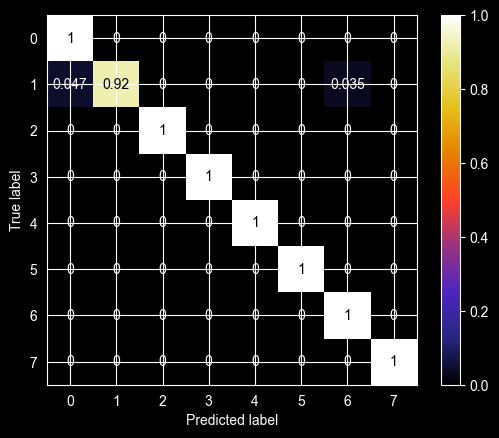

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cf = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=best_estimator_0.classes_)
disp.plot(cmap='CMRmap');

This model yields perfect performance excepting for class 1, which gets confused in ~8% cases either for class 0 or class 6.

## Model #2 - Logistic Regression with class weighting

Logistic regression allows class weighting: I'll apply it to possibly further address target class imbalance.

In [31]:
pipe = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('lr',  LogisticRegression(solver='saga', random_state=0, class_weight='balanced', max_iter=1000)),
])

params = {
    'lr__C': [0.1, 0.2, 0.5, 1, 2, 5, 10],
    'lr__l1_ratio': [0, 1],
}

grid = GridSearchCV(pipe, params, cv=5, n_jobs=-1, scoring='f1_weighted')
grid.fit(X_train, y_train)
best_estimator_1 = grid.best_estimator_

In [32]:
y_pred = best_estimator_1.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.997     1.000     0.998       618
           1      1.000     0.982     0.991       171
           2      1.000     1.000     1.000       427
           3      1.000     1.000     1.000       437
           4      1.000     1.000     1.000       285
           5      1.000     1.000     1.000       855
           6      1.000     1.000     1.000      2660
           7      1.000     1.000     1.000       133

    accuracy                          0.999      5586
   macro avg      1.000     0.998     0.999      5586
weighted avg      0.999     0.999     0.999      5586



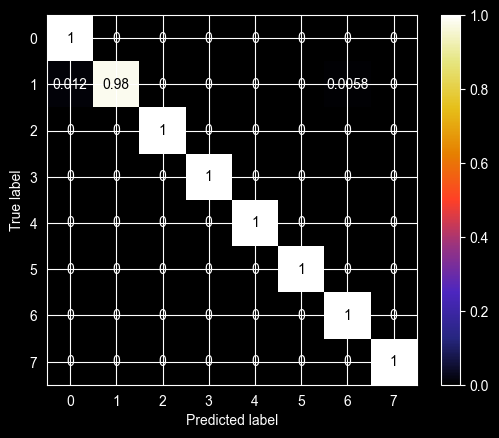

In [33]:
cf = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=best_estimator_1.classes_)
disp.plot(cmap='CMRmap');

Class weighting had an impact in solving part of previous misclassifications: class 1 gets confused only in ~2% cases either for class 0 or class 6.

## Model #3 - Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy', 'log_loss'],
}

rc = RandomForestClassifier(random_state=0)
grid = GridSearchCV(rc, params, cv=5, n_jobs=-1, scoring='f1_weighted')
grid.fit(X_train, y_train)
best_estimator_2 = grid.best_estimator_

In [35]:
y_pred = best_estimator_2.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.979     1.000     0.990       618
           1      1.000     0.883     0.938       171
           2      1.000     0.859     0.924       427
           3      0.995     1.000     0.998       437
           4      1.000     1.000     1.000       285
           5      1.000     1.000     1.000       855
           6      0.974     1.000     0.987      2660
           7      1.000     0.947     0.973       133

    accuracy                          0.984      5586
   macro avg      0.994     0.961     0.976      5586
weighted avg      0.985     0.984     0.984      5586



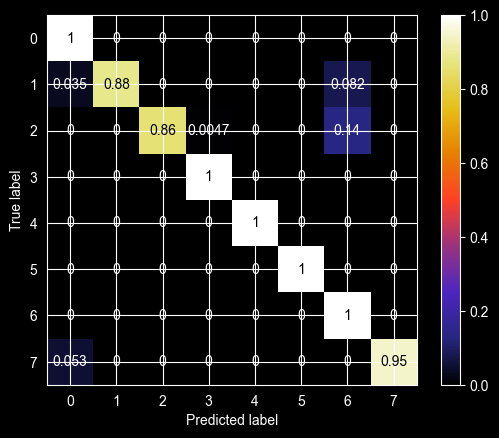

In [36]:
cf = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=best_estimator_2.classes_)
disp.plot(cmap='CMRmap');

This classifier provided less performing results than first 2 models, in particular when predicting class 1, 2 and 7.

# Model selection

Model #2 provided us with the highest performance: logistic regression with class weighting. Let's extract feature importances, starting with the DataFrame of 43 sets of coefficients, one per each of the 8 classes.

In [37]:
coeffs = best_estimator_1.named_steps['lr'].coef_
coeff_label = pd.MultiIndex(levels=[['0', '1', '2', '3', '4', '5', '6', '7'], [0,1,2,3,4,5,6,7]],
                             codes=[[0,0,0,0,0,0,0,0], [0,1,2,3,4,5,6,7]])
coefficients = pd.DataFrame(coeffs.T, columns=coeff_label)

coefficients.shape

(43, 8)

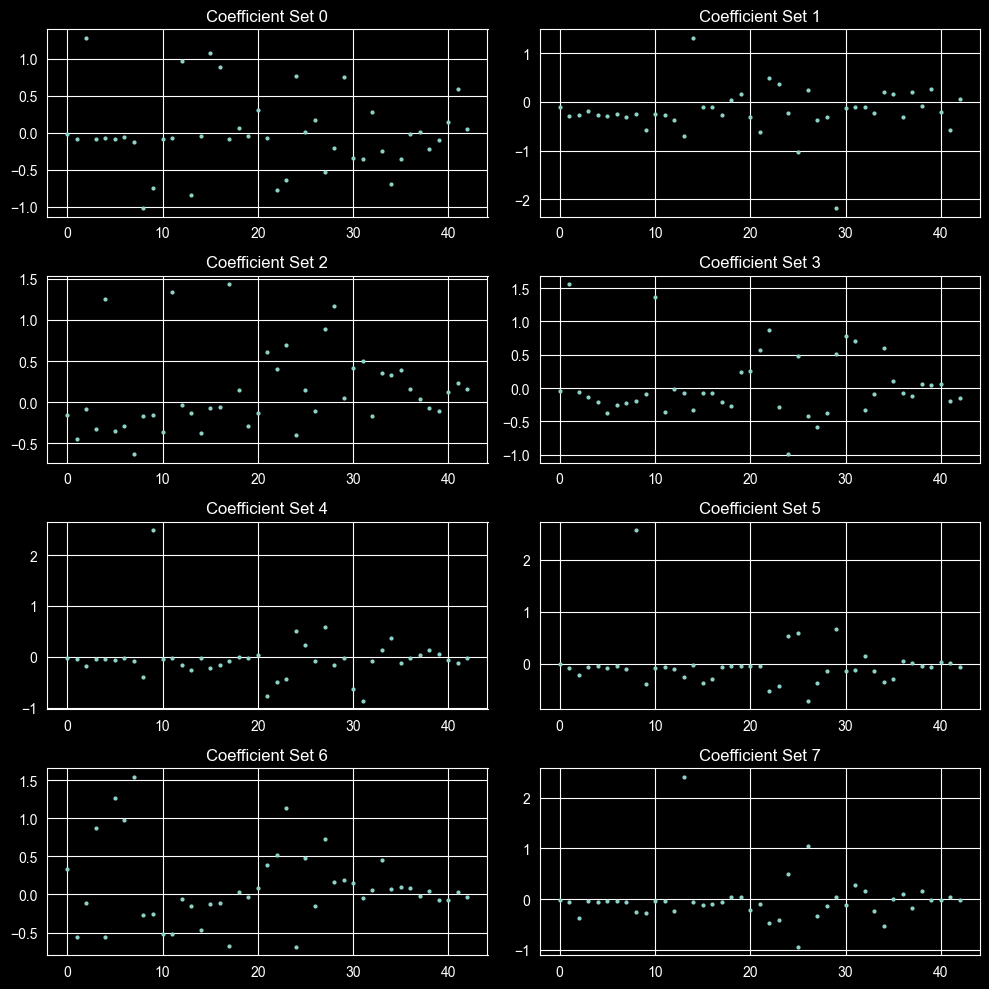

In [38]:
fig, axList = plt.subplots(nrows=4, ncols=2)
axList = axList.flatten()
fig.set_size_inches(10,10)

for ax in enumerate(axList):
    loc = ax[0]
    ax = ax[1]

    data = coefficients.xs(loc, level=1, axis=1)
    data.plot(marker='o', ls='', ms=2.0, ax=ax, legend=False)

    ax.set(title='Coefficient Set '+str(loc))

plt.tight_layout()

We can notice how the highest explanatory coefficients for each class pertain to the categorical variables about anomaly type (first 18 features). Let's observe more in detail the features yielding the maximum impact in the prediction for each class.

In [39]:
coefficients.set_index(X.columns, inplace=True)

coefficients.idxmax().to_frame(name='Highest-impact Features per Class')

Highest-impact Features per Class
0 0             cell_type_Elliptocyte
  1             cell_type_Smudge_Cell
  2       cell_type_Toxic_Granulation
  3              cell_type_Blast_Cell
  4                cell_type_Platelet
  5              cell_type_Normal_RBC
  6              cell_type_Neutrophil
  7             cell_type_Sickle_Cell

# Conclusions and next steps

The target life expectancy dataset was cleaned and preprocessed so as to be fed as input to a series of Classification models.

A simple classification model such as logistic regression is enough to properly solve classification problems in this dataset, both for binary and multilabel anomaly classification problems, especially when provided with class weighing functionality.

As shown in the feature coefficients analysis, it results that cell type is highly predictive of the cell anomaly type, for this particular dataset. A further study could be to investigate the problem without using the cell type information.

Copyright @ IBM Corporation. All rights reserved.
